In [1]:
import numpy as np
from scipy.fft import rfft, rfftfreq
#from scipy import signal
from scipy.integrate import quad


import matplotlib.pyplot as plt

In [2]:
# def inhomogeneous_poisson_process(f, T, rate=1):
#     '''
#     f : rate function (should be non-negative; 
#         will be normalized to probabilities)
#     T : time span
#     rate : N_total / T
    
#     returns sorted np array of event times 
#     in interval [0, T)
#     '''
    
#     n = np.random.poisson(rate * T) # number of events
    
#     norm = quad(f, 0, T)[0]
        
#     events = []
#     while len(events) < n:
#         t = np.random.rand() * T
#         if np.random.rand() < f(t) / norm:
#             events.append(t)
            
#     return np.sort(events)         

In [41]:
# this is faster than the one above
def inhomogeneous_poisson_process(f, T, rate=1):
    #     '''
#     f : rate function (should be non-negative; 
#         will be normalized to probabilities)
#     T : time span
#     rate : N_total / T
    
#     returns sorted np array of event times 
#     in interval [0, T)
#     '''

    # Determine how many events to generate
    n = np.random.poisson(rate * T)
    
    # Calculate the integral for the PDF
    norm = quad(f, 0, T)[0]
    
    # Find the max of f(t) to set an efficient rejection ceiling
    # This ensures the 'h' threshold is scaled to your function
    t_samples = np.linspace(0, T, 1000)
    f_max = np.max([f(t) for t in t_samples])
    p_max = f_max / norm
        
    events = []
    while len(events) < n:
        t = np.random.uniform(0, T)
        h = np.random.uniform(0, p_max) # Scaled to the function's peak
        if h < f(t) / norm:
            events.append(t)
            
    return np.sort(events)

In [42]:
# time dependent, positive rate function
# p - modulation amplitude
# f - frequency of modulation
rate_func = lambda p, f: lambda t: 1 + p*np.cos(2 * np.pi * f * t)    

In [43]:
# creates list of times at which the events are recorded
data = inhomogeneous_poisson_process(rate_func(0.5, 1 / 28), 1000)

In [44]:
data

array([  1.59369166,   3.0001271 ,   3.79908098, ..., 996.74765987,
       997.21837673, 999.15522087])

In [45]:
#These paramters need to be estimated to be able to correctly perform and visualize DFT
T = data.max() - data.min()
df = 1 / T
dt=0.1
fmax = 1 / (2 * dt) 
Nevents=len(data)

print("Time span of the data: ", T)
print("Natural frequency resolution:", df)
print("Sampling rate (time bin size):", dt)
print("Number of time bins:", T/dt)
print("Nyquist (maximum accesible) frequency:", fmax)
print("Number of independent frequencies:", fmax/df)
print("Number of events:", Nevents)


Time span of the data:  997.5615292114563
Natural frequency resolution: 0.0010024444314632615
Sampling rate (time bin size): 0.1
Number of time bins: 9975.615292114562
Nyquist (maximum accesible) frequency: 5.0
Number of independent frequencies: 4987.807646057281
Number of events: 1017


In [46]:
# Bin time series
# bins_edges = np.histogram_bin_edges(data, bins='auto')

bins_edges = np.arange(data.min(), data.max(), dt)

binned_data = np.histogram(data, bins=bins_edges)[0]

In [47]:
np.sum(binned_data)

1016

In [48]:
bins_edges

array([  1.59369166,   1.69369166,   1.79369166, ..., 998.89369166,
       998.99369166, 999.09369166])

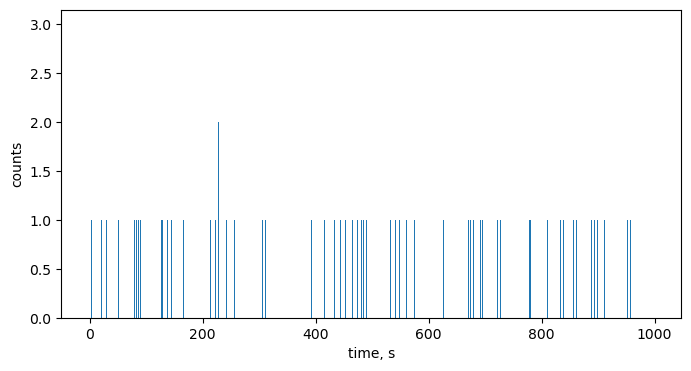

In [49]:
plt.figure(figsize=(8, 4))
plt.bar(bins_edges[:-1] - data.min(), binned_data, dt)
plt.xlabel('time, s')
plt.ylabel('counts')
plt.show()

Length of Fourier power array:  4988


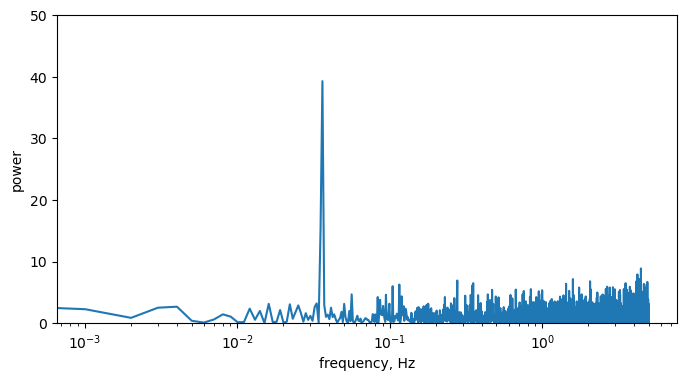

In [50]:
# Fourier power properly normalized to be distributed as chi-squared with 2 degrees of freedom
power = np.abs(rfft(binned_data))**2 /Nevents
# Note that the length of the power array is equal to the number of statistically independent frequencies calculated above
n = power.size
print("Length of Fourier power array: ", n)
#frequency assignments 
freqs = np.arange(n) * df

plt.figure(figsize=(8, 4))
plt.semilogx(freqs, power)
plt.ylim(0, 50)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.16g}'))
plt.xlabel('frequency, Hz')
plt.ylabel('power')
plt.show()